In [1]:
import pathpyG as pp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
import contextily as cx
import folium

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/clean/"))

metadata = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_metadata_all.csv"), dtype={"site_id": str, "huc8": str})

## Visualize streamgague locations

In [ ]:
geometry = gpd.points_from_xy(metadata["longitude"], metadata["latitude"])

gdf01 = gpd.GeoDataFrame(metadata, geometry=geometry, crs="EPSG:4326")

gdf = pd.concat([gdf01])

center_lat = gdf["latitude"].mean()
center_lon = gdf["longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8,
    tiles="OpenStreetMap"
)

fg1 = folium.FeatureGroup(name="Stream gauges 02040101")

for _, row in gdf01.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color="red",
        fill=True,
        fill_color="red",
        popup=f"Site ID: {row['site_id']} \n Site Name: {row['site_name']}"
    ).add_to(fg1)

fg1.add_to(m)

folium.LayerControl().add_to(m)

m.save("stream_gauges_map_subbasin.html")

### Static map

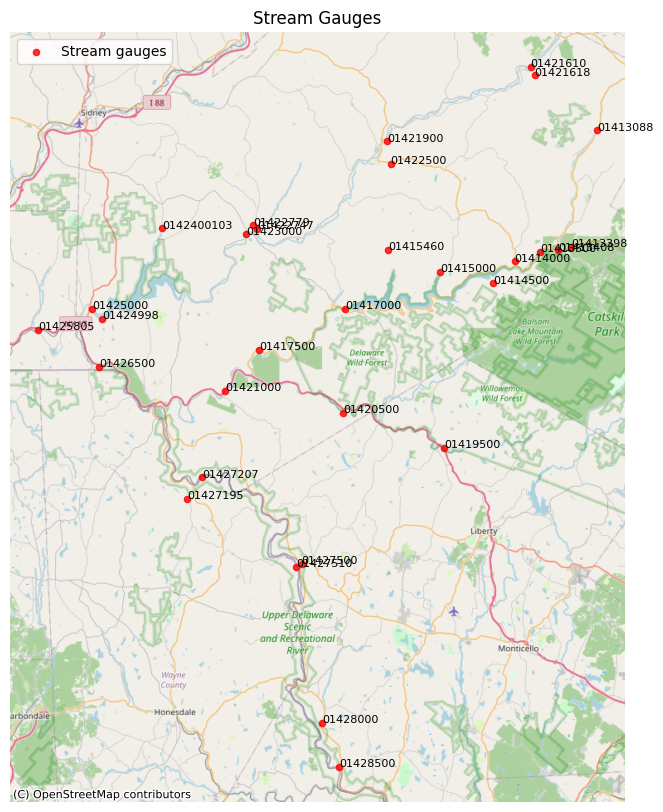

In [ ]:
gdf = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10,10))

gdf.plot(
    ax=ax,
    color="red",
    markersize=20,
    alpha=0.8,
    label="Stream gauges"
)

# Add basemap 
cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
ax.legend(loc="upper left")
# Add labels
for x, y, label in zip(gdf.geometry.x, gdf.geometry.y, gdf["site_id"]):
    ax.text(x, y, str(label),fontsize=8)

plt.title("Stream Gauges")
plt.show()

## Rename sites and create directed graph

In [2]:
id_conversion = pd.read_csv('site_id_naming_reference.csv', dtype={'site_id': str})

metadata = metadata.merge(id_conversion[['site_id', 'site_rename']], on='site_id', how='left')
metadata['site_rename'] = metadata['site_rename'].str.replace(' ', '', regex=False)

metadata[['site_id', 'site_name', 'site_rename']]


,site_id,site_name,site_rename
0,01413088,EAST BRANCH DELAWARE RIVER AT ROXBURY NY,site18
1,01413398,BUSH KILL NEAR ARKVILLE NY,site19
2,01413408,DRY BROOK AT ARKVILLE,site20
3,01413500,EAST BRANCH DELAWARE RIVER AT MARGARETVILLE NY,site21
4,01414000,PLATTE KILL AT DUNRAVEN NY,site22
5,01414500,MILL BROOK NEAR DUNRAVEN NY,site23
6,01415000,TREMPER KILL NEAR ANDES NY,site24
7,01415460,TERRY CLOVE KILL NEAR DE LANCEY NY,site25
8,01417000,EAST BRANCH DELAWARE RIVER AT DOWNSVILLE NY,site26
9,01417500,EAST BRANCH DELAWARE RIVER AT HARVARD NY,site27


In [3]:
graph_edges = [("site0", "site2"), 
              ("site1", "site2"),
              ("site2", "site6"),
              ("site3", "site6"),
              ("site4", "site6"),
              ("site5", "site6"),
              ("site6", "site8"), #note site 6 and 7 both flow into the reservoir but from differennt brances
              ("site7", "site8"), #note site 8 is after the reservoir
              ("site8", "site9"),
              ("site9", "site11"),
              ("site10", "site11"),
              ("site11", "site13"),
              ("site12", "site13"),
              ("site13", "site15"),
              ("site14", "site15"),
              ("site15", "site17"),
              ("site16", "site17")] 


graph_edges02 = [("site18", "site21"),
              ("site19", "site20"),
              ("site20", "site21"),
              ("site21", "site26"), # NOTE site 26 is th outlet of the Pepcaton reservoir so all these other sites lead to the reservoir
              ("site22", "site26"),
              ("site23", "site26"),
              ("site24", "site26"),
              ("site25", "site26"),
              ("site26", "site27"),
              ("site27", "site30"),
              ("site28", "site29"),
              ("site29", "site30")]


graph_edges_all = graph_edges + graph_edges02 + [("site30", "site13")] # point of connection between the two subbasins

In [ ]:
river_network = pp.Graph.from_edge_list(graph_edges_all)

A = river_network.sparse_adj_matrix()

group0 = ("site0", "site1", "site2", "site3", "site4", "site5", "site6", "site7", "site8", "site9", "site10", "site11", "site12", "site13", "site14", "site15", "site16", "site17")
group1 = ("site18", "site19", "site20", "site21", "site22", "site23", "site24", "site25", "site26", "site27", "site28", "site29", "site30")
z= []
for i, node in enumerate(river_network.nodes):
    if node in group0:
        z.append(0)
    elif node in group1:
        z.append(1)

colors = {0: 'red', 1: 'blue'}
pp.plot(river_network, node_color = [colors[z[river_network.mapping.to_idx(x)]] for x in river_network.nodes], node_label = [x for x in river_network.mapping.node_ids]);

### Compute summary statistics

In [2]:
import pathpyG as pp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
import contextily as cx
import folium

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), "../../data/clean/"))

metadata = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022_metadata_all.csv"), dtype={"site_id": str, "huc8": str})

id_conversion = pd.read_csv('site_id_naming_reference.csv', dtype={'site_id': str})

metadata = metadata.merge(id_conversion[['site_id', 'site_rename']], on='site_id', how='left')
metadata['site_rename'] = metadata['site_rename'].str.replace(' ', '', regex=False)

metadata[['site_id', 'site_name', 'site_rename']]


,site_id,site_name,site_rename
0,01413088,EAST BRANCH DELAWARE RIVER AT ROXBURY NY,site18
1,01413398,BUSH KILL NEAR ARKVILLE NY,site19
2,01413408,DRY BROOK AT ARKVILLE,site20
3,01413500,EAST BRANCH DELAWARE RIVER AT MARGARETVILLE NY,site21
4,01414000,PLATTE KILL AT DUNRAVEN NY,site22
5,01414500,MILL BROOK NEAR DUNRAVEN NY,site23
6,01415000,TREMPER KILL NEAR ANDES NY,site24
7,01415460,TERRY CLOVE KILL NEAR DE LANCEY NY,site25
8,01417000,EAST BRANCH DELAWARE RIVER AT DOWNSVILLE NY,site26
9,01417500,EAST BRANCH DELAWARE RIVER AT HARVARD NY,site27


<Figure size 1200x600 with 0 Axes>

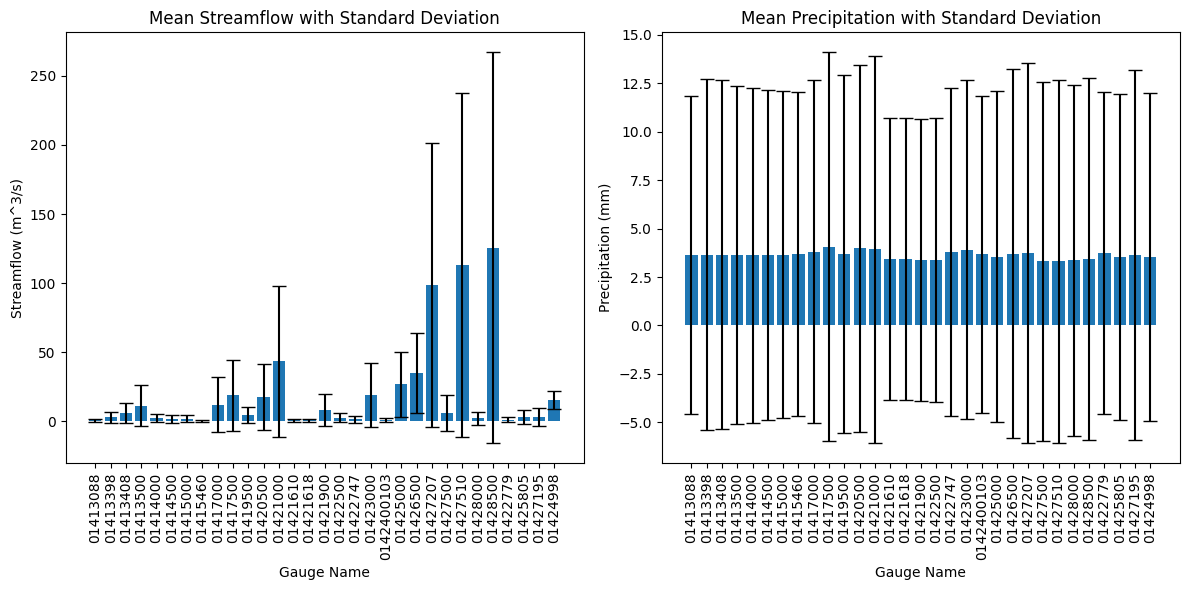

In [3]:
streamflow = pd.read_csv(os.path.join(DATA_DIR, "streamflow_wy2022.csv"), dtype={"site_id": str, "huc8": str})
streamflow.columns = streamflow.columns.astype(str)
precipitation = pd.read_csv(os.path.join(DATA_DIR, "precipitation_wy2022.csv"), dtype={"site_id": str, "huc8": str})
precipitation.columns = precipitation.columns.astype(str)

site_ids = [col for col in streamflow.columns if col != "date"]

mean_streamflow = []
std_streamflow = []
mean_precipitation = []
std_precipitation = []

for site_id in site_ids:
    mean_streamflow.append(streamflow[site_id].mean())
    std_streamflow.append(streamflow[site_id].std())
    mean_precipitation.append(precipitation[site_id].mean())
    std_precipitation.append(precipitation[site_id].std())

plt.figure(figsize=(12, 6))
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].bar(site_ids, mean_streamflow, yerr=std_streamflow, capsize=5)
axes[0].tick_params(axis="x", labelrotation=90)
axes[0].set_title("Mean Streamflow with Standard Deviation")
axes[0].set_ylabel("Streamflow (m^3/s)")
axes[0].set_xlabel("Gauge Name")

axes[1].bar(site_ids, mean_precipitation, yerr=std_precipitation, capsize=5)
axes[1].tick_params(axis="x", labelrotation=90)
axes[1].set_title("Mean Precipitation with Standard Deviation")
axes[1].set_ylabel("Precipitation (mm)")
axes[1].set_xlabel("Gauge Name")
plt.tight_layout()
plt.savefig("figures/mean_std_streamflow_precipitation.png", dpi=300);